# ============================================================
# 03_li_attempts_analysis.ipynb — Halight Performance Intelligence
# ============================================================
# PURPOSE:
#   Deep-dive analysis of learning item attempts (li_attempts table)
#   This is the primary behavioural event table — every time a user
#   attempts a learning item, one row is created here.
#
# TABLES USED:
#   li_attempts     — raw attempt events (primary table)
#   users_business  — loaded from data/staging/ (already cleaned)
#
# OUTPUTS:
#   data/marts/li_attempts_metrics.parquet — per-user learning features
#   data/marts/content_performance.parquet  — per learning-item stats
#
# DASHBOARD PAGES FED:
#   Page 1 — Total Attempts KPI
#   Page 3 — Avg Attempts per User, Avg Score, Active Days, Completion Rates
#   Page 4 — Learning engagement per user (churn model features)
# ============================================================

In [1]:
import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.aws.fetch_tables import fetch_attempts
from src.utils.helpers import load_clean_data, save_mart

print('✅ Imports loaded')
print(f'   Project root: {PROJECT_ROOT}')

✅ Imports loaded
   Project root: d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence


In [2]:
# ============================================================
# LOAD DATA
# li_attempts — fetched once from Athena, cached as parquet
# users_business — pre-cleaned from 01_user_analysis
# ============================================================
li = fetch_attempts(force_refresh=False)
print(f'li_attempts shape: {li.shape}')

# Load cleaned users table from staging
STAGING_PATH = os.path.join(PROJECT_ROOT, 'data', 'staging', 'users_business.parquet')
users_biz = pd.read_parquet(STAGING_PATH)
print(f'users_business shape: {users_biz.shape}')

li.head()

🔄 Querying Athena (this runs ONCE then caches locally)...
   Query: SELECT * FROM li_attempts
✅ Done! Cached as: data/raw/li_attempts.parquet  (30,211,219 rows | 1539.7 MB)
   Next time this runs instantly from cache.
li_attempts shape: (30211219, 26)
users_business shape: (295765, 72)


,instance_id,generated_for_date,generated_ts,attempt_insert_ts,user_id,attempt_id,start_ts,end_ts,score,duration_in_mins,...,content_upload_lang_id,learning_item_id,authorized_by_user_id,launcher_id,launcher_title,revoked_by_user_id,is_revoked,revoked_ts,is_updated,last_updated_ts
0,0D931F9BE850FCAB0BB1C42424187996,2023-03-16,2023-03-17 04:30:21,2023-03-16 14:40:08,10040,13081,2023-03-16 14:40:01,2023-03-16 14:40:08.000,NaN,0.12,...,<NA>,209,<NA>,4,Unlayer,<NA>,0,NaT,0,2023-03-16 14:40:08
1,0D90AF0E048EDA389A6ABD0719057E17,2025-05-21,2025-05-22 04:01:00,2025-05-21 08:19:18,10935,20161,2025-05-21 07:41:17,2025-05-21 08:19:18.000,NaN,33.00,...,fr-FR,232,<NA>,4,Rustici Engine,<NA>,0,NaT,0,2025-05-21 08:19:18
2,0D90AF0E048EDA389A6ABD0719057E17,2025-05-21,2025-05-22 04:01:00,2025-05-21 14:38:35,10356,20181,2025-05-19 16:39:15,2025-05-21 14:38:35.000,100.0,124.00,...,<NA>,241,<NA>,4,Rustici Engine,<NA>,0,NaT,0,2025-05-21 14:38:35
3,0D931F9BE850FCAB0BB1C42424187996,2022-10-10,2022-10-11 04:30:29,2022-10-10 10:49:31,10593,6181,2022-10-10 10:48:09,2022-10-10 10:49:31.000,80.0,1.37,...,<NA>,132,<NA>,1,Monsoon,<NA>,0,NaT,0,2022-10-10 10:49:31
4,1625E189E00C17624201AB5919DC12F8,2022-06-05,2022-06-06 04:20:25,2022-06-05 11:06:08,9176,1142486,2022-06-05 11:00:40,2022-06-05 11:06:08.000,100.0,5.47,...,en-GB,854,<NA>,1,Monsoon,<NA>,0,NaT,0,2022-06-05 11:06:08


---
## PART 1: SCHEMA INSPECTION & DATA QUALITY
---

In [3]:
# Schema overview
print('SCHEMA OVERVIEW')
print('=' * 40)
print(f'Rows:    {len(li):,}')
print(f'Columns: {li.shape[1]}')
print(f'\nColumn names and types:')
print(li.dtypes)
print(f'\nKey Columns:')
print('  user_id       — links to users table')
print('  attempt_id    — unique attempt identifier')
print('  learning_item_id — the content being attempted')
print('  start_ts / end_ts — when the attempt happened')
print('  score         — 0–100, NULL if not a scored item')
print('  duration_in_mins — how long the user spent')
print('  status_title  — Passed / Failed / Incomplete / etc.')
print('  is_pass       — 1 if passed, 0 if not')
print('  is_revoked    — 1 if the attempt was voided')

SCHEMA OVERVIEW
Rows:    30,211,219
Columns: 26

Column names and types:
instance_id                      string[python]
generated_for_date                       object
generated_ts                     datetime64[ns]
attempt_insert_ts                datetime64[ns]
user_id                          string[python]
attempt_id                       string[python]
start_ts                         datetime64[ns]
end_ts                                   object
score                                   float32
duration_in_mins                        float32
status_id                        string[python]
status_title                     string[python]
is_pass                                   Int32
origin                           string[python]
attempt_token                    string[python]
content_upload_version_number             Int32
content_upload_lang_id           string[python]
learning_item_id                 string[python]
authorized_by_user_id            string[python]
launcher_id    

In [4]:
# Null analysis
null_pct = (li.isnull().sum() / len(li) * 100).sort_values(ascending=False)
print('NULL PERCENTAGES (columns with any nulls):')
print(null_pct[null_pct > 0].round(1).to_string())

NULL PERCENTAGES (columns with any nulls):
revoked_by_user_id               99.7
revoked_ts                       99.7
content_upload_lang_id           95.3
authorized_by_user_id            82.0
score                            31.1
launcher_id                      30.4
launcher_title                   30.4
content_upload_version_number    30.4
attempt_token                    30.4
start_ts                         30.4
duration_in_mins                 19.9


In [5]:
# Duplicate check on attempt_id
total     = len(li)
unique_attempts = li['attempt_id'].nunique()
unique_users    = li['user_id'].nunique()
print(f'Total rows:        {total:,}')
print(f'Unique attempt_id: {unique_attempts:,}')
print(f'Unique users:      {unique_users:,}')
print(f'Avg attempts/user: {total/unique_users:.1f}')

dups = total - unique_attempts
if dups > 0:
    print(f'\n⚠️  {dups:,} duplicate attempt_ids found — Athena daily snapshot duplicates')
    print('   Will deduplicate on attempt_id keeping latest generated_for_date')
else:
    print('\n✅ No duplicate attempt_ids — each row is a unique attempt event')

Total rows:        30,211,219
Unique attempt_id: 9,076,329
Unique users:      251,416
Avg attempts/user: 120.2

⚠️  21,134,890 duplicate attempt_ids found — Athena daily snapshot duplicates
   Will deduplicate on attempt_id keeping latest generated_for_date


In [6]:
# Date range
li['start_ts'] = pd.to_datetime(li['start_ts'], errors='coerce')
li['end_ts']   = pd.to_datetime(li['end_ts'],   errors='coerce')
print(f'start_ts range: {li["start_ts"].min().date()}  →  {li["start_ts"].max().date()}')
print(f'Null start_ts:  {li["start_ts"].isna().sum():,}')
print(f'Null end_ts:    {li["end_ts"].isna().sum():,}')

start_ts range: 2017-04-12  →  2026-03-08
Null start_ts:  9,189,211
Null end_ts:    1


---
## PART 2: DATA CLEANING
---

In [7]:
# ================================================================
# CLEANING STEPS
# 1. Remove Athena snapshot duplicates (keep latest per attempt_id)
# 2. Remove revoked attempts (is_revoked = 1) — voided by admins
# 3. Remove rows with null user_id (orphaned records)
# 4. Remove rows with null start_ts (unusable for time analysis)
# 5. Drop metadata / system columns not needed for analysis
# 6. Calculate duration sanity check (flag extreme values)
# ================================================================

li_clean = li.copy()

# 1. Deduplicate on attempt_id
if 'generated_for_date' in li_clean.columns:
    li_clean = li_clean.sort_values('generated_for_date', ascending=False)
before = len(li_clean)
li_clean = li_clean.drop_duplicates(subset=['attempt_id'])
print(f'1. Dedup: removed {before - len(li_clean):,} snapshot duplicates')

# 2. Remove revoked attempts
if 'is_revoked' in li_clean.columns:
    revoked = li_clean['is_revoked'].eq(1).sum()
    li_clean = li_clean[li_clean['is_revoked'] != 1]
    print(f'2. Revoked attempts removed: {revoked:,}')

# 3. Remove null user_id
null_uid = li_clean['user_id'].isna().sum()
li_clean = li_clean.dropna(subset=['user_id'])
print(f'3. Null user_id removed: {null_uid:,}')

# 4. Remove null start_ts
null_ts = li_clean['start_ts'].isna().sum()
li_clean = li_clean.dropna(subset=['start_ts'])
print(f'4. Null start_ts removed: {null_ts:,}')

# 5. Drop metadata columns
meta_drop = ['instance_id','generated_for_date','generated_ts',
             'attempt_token','content_upload_version_number',
             'content_upload_lang_id','authorized_by_user_id',
             'launcher_id','revoked_by_user_id','is_updated','last_updated_ts']
meta_drop = [c for c in meta_drop if c in li_clean.columns]
li_clean = li_clean.drop(columns=meta_drop)
print(f'5. Metadata columns dropped: {len(meta_drop)}')

# 6. Duration sanity — flag extreme values (>480 min = 8 hours is implausible for one LI)
if 'duration_in_mins' in li_clean.columns:
    extreme = (li_clean['duration_in_mins'] > 480).sum()
    li_clean['duration_in_mins'] = li_clean['duration_in_mins'].clip(upper=480)
    print(f'6. Duration capped at 480 min for {extreme:,} extreme records')

print(f'\nCleaned shape: {li_clean.shape}')

1. Dedup: removed 21,134,890 snapshot duplicates
2. Revoked attempts removed: 88,275
3. Null user_id removed: 0
4. Null start_ts removed: 2,408,274
5. Metadata columns dropped: 11
6. Duration capped at 480 min for 33,532 extreme records

Cleaned shape: (6579780, 15)


In [8]:
# Fill remaining nulls
if 'score' in li_clean.columns:
    li_clean['score'] = li_clean['score'].fillna(-1)  # -1 = no score (not a scored item)
if 'duration_in_mins' in li_clean.columns:
    li_clean['duration_in_mins'] = li_clean['duration_in_mins'].fillna(0)
if 'is_pass' in li_clean.columns:
    li_clean['is_pass'] = li_clean['is_pass'].fillna(0)
print('Null fills applied. Final null check:')
remaining = li_clean.isnull().sum()
print(remaining[remaining > 0].to_string() if remaining.sum() > 0 else 'No remaining nulls')

Null fills applied. Final null check:
revoked_ts    6579780


In [9]:
# Add time features for trend analysis
li_clean['attempt_month']   = li_clean['start_ts'].dt.to_period('M')
li_clean['attempt_week']    = li_clean['start_ts'].dt.to_period('W')
li_clean['attempt_weekday'] = li_clean['start_ts'].dt.day_name()
li_clean['attempt_hour']    = li_clean['start_ts'].dt.hour
print('Time features added: attempt_month, attempt_week, attempt_weekday, attempt_hour')

Time features added: attempt_month, attempt_week, attempt_weekday, attempt_hour


---
## PART 3: UNIVARIATE ANALYSIS
---

ATTEMPT STATUS DISTRIBUTION:
  Pass                     : 6,519,675 (99.1%)
  Fail                     :   60,105 (0.9%)


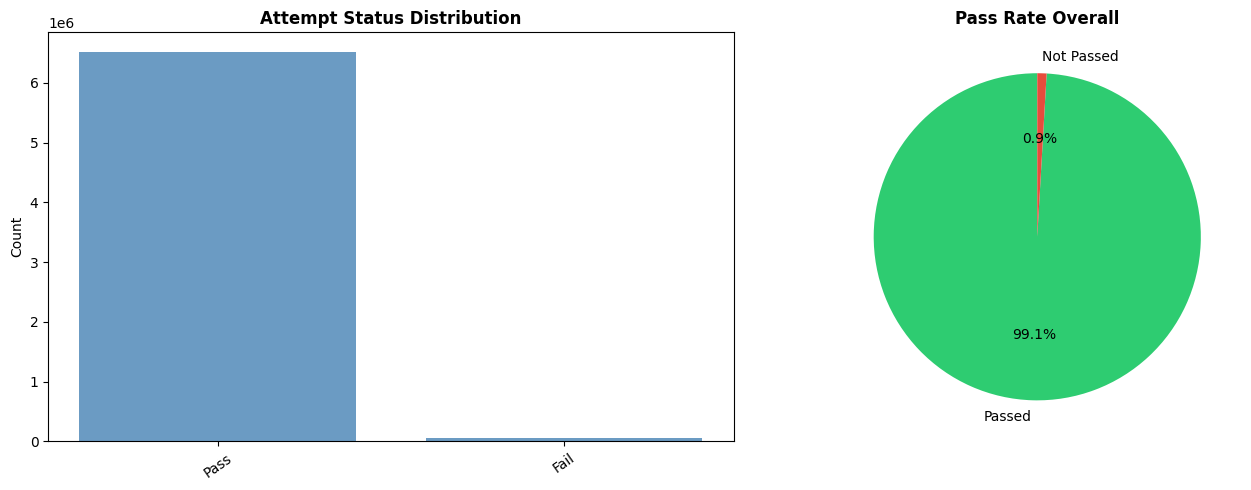


Overall Pass Rate: 99.1%


In [10]:
# STATUS DISTRIBUTION — what is the outcome of most attempts?
print('ATTEMPT STATUS DISTRIBUTION:')
status_counts = li_clean['status_title'].value_counts()
for status, cnt in status_counts.items():
    print(f'  {str(status):<25}: {cnt:>8,} ({cnt/len(li_clean)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
top_status = li_clean['status_title'].value_counts().head(8)
axes[0].bar(top_status.index, top_status.values, color='steelblue', alpha=0.8)
axes[0].set_title('Attempt Status Distribution', fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=35)

# Pass vs Not-pass pie
passed    = li_clean['is_pass'].eq(1).sum()
not_passed = len(li_clean) - passed
axes[1].pie([passed, not_passed], labels=['Passed','Not Passed'],
            colors=['#2ecc71','#e74c3c'], autopct='%1.1f%%', startangle=90)
axes[1].set_title('Pass Rate Overall', fontweight='bold')
plt.tight_layout()
plt.show()

pass_rate = passed / len(li_clean) * 100
print(f'\nOverall Pass Rate: {pass_rate:.1f}%')

Scored attempts: 4,638,971 (70.5% of total)

Score Statistics:
count    4638971.00
mean          98.29
std            8.99
min            0.00
25%          100.00
50%          100.00
75%          100.00
max          100.00
Name: score, dtype: float64


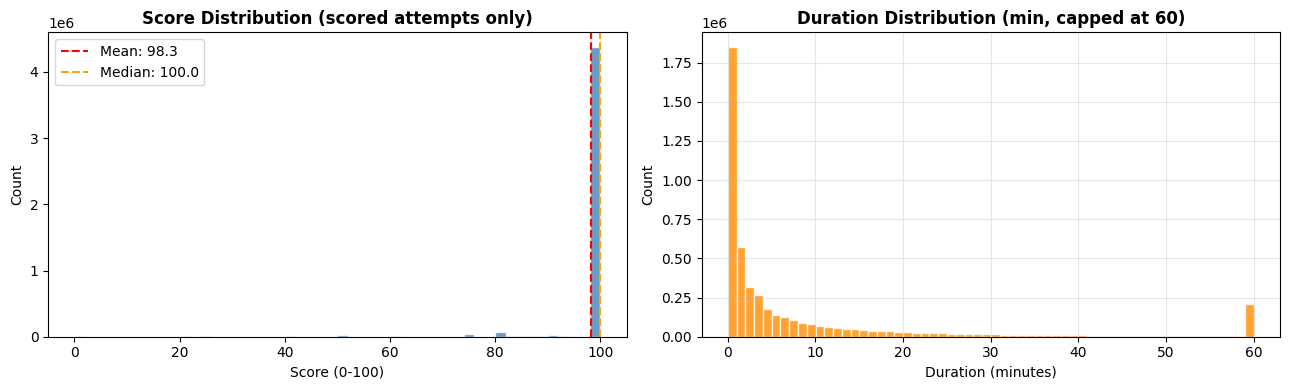

In [11]:
# SCORE DISTRIBUTION
scored = li_clean[li_clean['score'] >= 0]  # exclude -1 (unscored items)
print(f'Scored attempts: {len(scored):,} ({len(scored)/len(li_clean)*100:.1f}% of total)')
print(f'\nScore Statistics:')
print(scored['score'].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(scored['score'].dropna(), bins=50, color='steelblue', alpha=0.8, edgecolor='white')
axes[0].axvline(scored['score'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {scored["score"].mean():.1f}')
axes[0].axvline(scored['score'].median(), color='orange', linestyle='--', linewidth=1.5,
                label=f'Median: {scored["score"].median():.1f}')
axes[0].set_title('Score Distribution (scored attempts only)', fontweight='bold')
axes[0].set_xlabel('Score (0-100)'); axes[0].set_ylabel('Count')
axes[0].legend()

axes[1].hist(li_clean['duration_in_mins'][li_clean['duration_in_mins'] > 0].clip(upper=60),
             bins=60, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title('Duration Distribution (min, capped at 60)', fontweight='bold')
axes[1].set_xlabel('Duration (minutes)'); axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

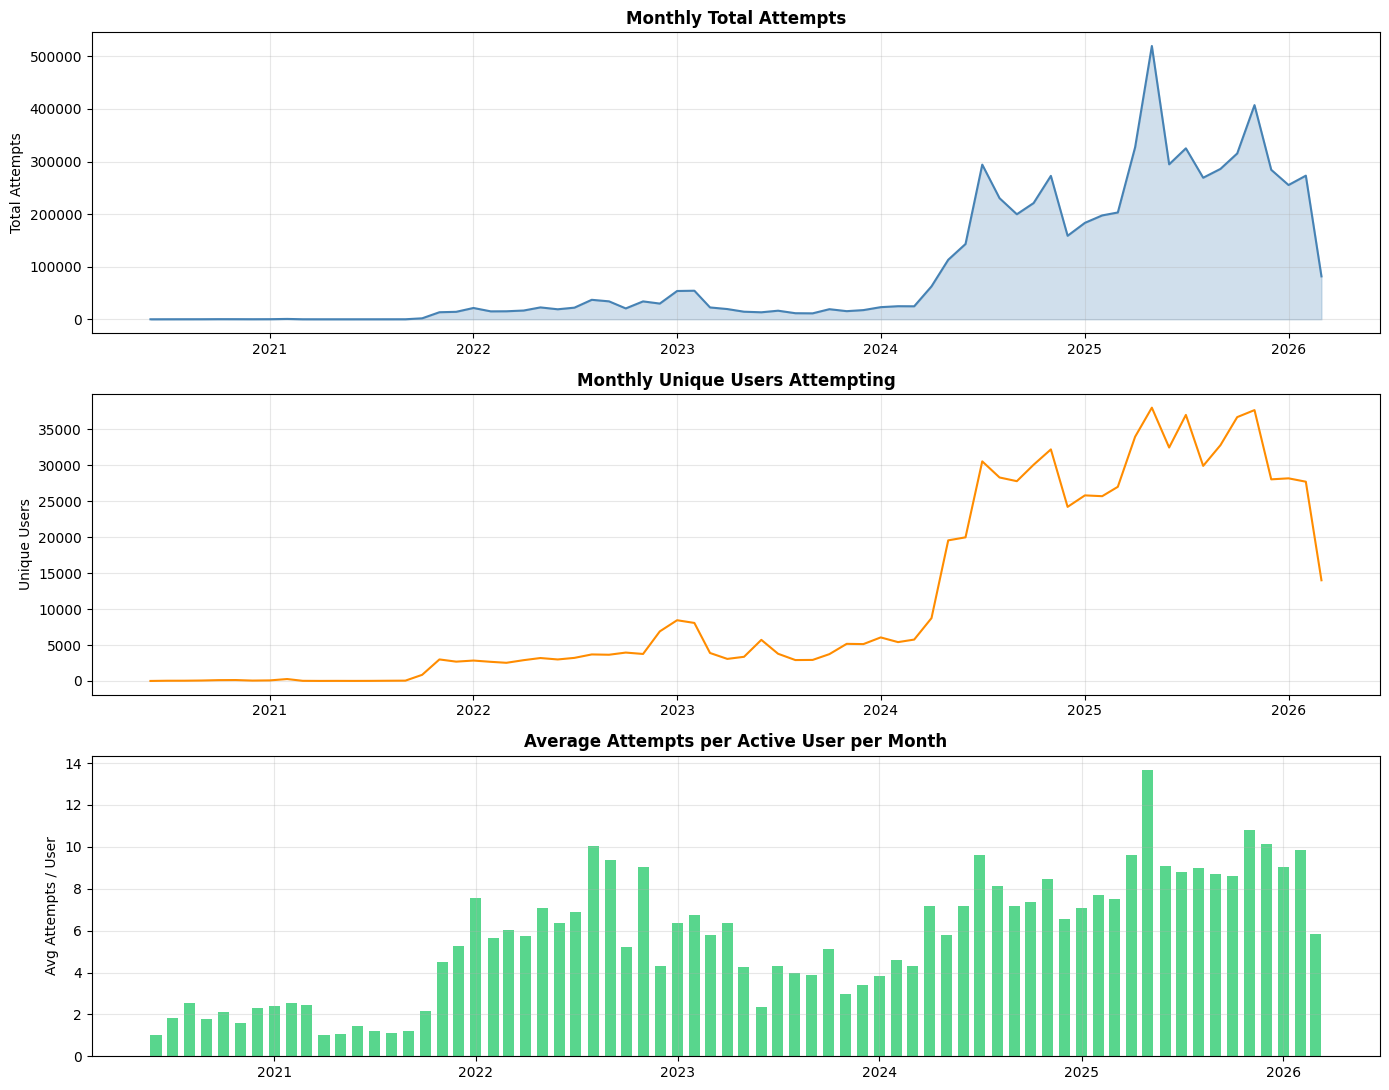

Last 12 months:
attempt_month  attempts  unique_users  avg_attempts_per_user
      2025-04    327169         33973                   9.63
      2025-05    519761         38018                  13.67
      2025-06    294704         32473                   9.08
      2025-07    325146         37012                   8.78
      2025-08    269219         29919                   9.00
      2025-09    286032         32803                   8.72
      2025-10    315389         36703                   8.59
      2025-11    407320         37679                  10.81
      2025-12    284266         28047                  10.14
      2026-01    255364         28187                   9.06
      2026-02    273145         27720                   9.85
      2026-03     81597         14007                   5.83


In [12]:
# ATTEMPTS OVER TIME — monthly trend
monthly_attempts = li_clean.groupby('attempt_month').size().reset_index(name='attempts')
monthly_attempts['month_dt'] = monthly_attempts['attempt_month'].dt.to_timestamp()

# Also track monthly unique users attempting
monthly_users = li_clean.groupby('attempt_month')['user_id'].nunique().reset_index(name='unique_users')
monthly_attempts = monthly_attempts.merge(
    monthly_users, on='attempt_month', how='left'
)
monthly_attempts['avg_attempts_per_user'] = (
    monthly_attempts['attempts'] / monthly_attempts['unique_users']
).round(2)

fig, axes = plt.subplots(3, 1, figsize=(14, 11))
axes[0].plot(monthly_attempts['month_dt'], monthly_attempts['attempts'],
             color='steelblue', linewidth=1.5)
axes[0].fill_between(monthly_attempts['month_dt'], monthly_attempts['attempts'],
                     alpha=0.25, color='steelblue')
axes[0].set_title('Monthly Total Attempts', fontweight='bold')
axes[0].set_ylabel('Total Attempts'); axes[0].grid(True, alpha=0.3)

axes[1].plot(monthly_attempts['month_dt'], monthly_attempts['unique_users'],
             color='darkorange', linewidth=1.5)
axes[1].set_title('Monthly Unique Users Attempting', fontweight='bold')
axes[1].set_ylabel('Unique Users'); axes[1].grid(True, alpha=0.3)

axes[2].bar(monthly_attempts['month_dt'],
            monthly_attempts['avg_attempts_per_user'],
            width=20, color='#2ecc71', alpha=0.8)
axes[2].set_title('Average Attempts per Active User per Month', fontweight='bold')
axes[2].set_ylabel('Avg Attempts / User'); axes[2].grid(True, alpha=0.3)

plt.tight_layout(); plt.show()
print('Last 12 months:')
print(monthly_attempts.tail(12)[
    ['attempt_month','attempts','unique_users','avg_attempts_per_user']
].to_string(index=False))

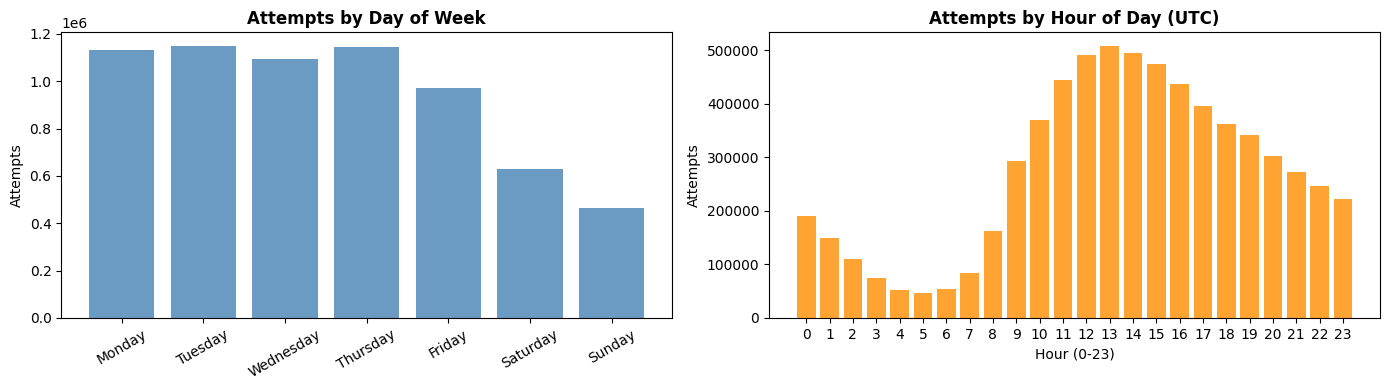

Peak day:  Tuesday (1,148,911 attempts)
Peak hour: 13:00  (508,053 attempts)


In [13]:
# WEEKLY & HOURLY ACTIVITY PATTERNS — when do users engage?
day_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
weekday_counts = li_clean['attempt_weekday'].value_counts().reindex(day_order).fillna(0)
hour_counts    = li_clean['attempt_hour'].value_counts().sort_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].bar(weekday_counts.index, weekday_counts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Attempts by Day of Week', fontweight='bold')
axes[0].set_ylabel('Attempts'); axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(hour_counts.index, hour_counts.values, color='darkorange', alpha=0.8, width=0.8)
axes[1].set_title('Attempts by Hour of Day (UTC)', fontweight='bold')
axes[1].set_ylabel('Attempts'); axes[1].set_xlabel('Hour (0-23)')
axes[1].set_xticks(range(0, 24))
plt.tight_layout(); plt.show()

print(f'Peak day:  {weekday_counts.idxmax()} ({weekday_counts.max():,} attempts)')
print(f'Peak hour: {hour_counts.idxmax()}:00  ({hour_counts.max():,} attempts)')

---
## PART 4: CONTENT PERFORMANCE ANALYSIS
---

In [14]:
# LEARNING ITEM (CONTENT) PERFORMANCE
# Which content is most attempted? What passes/fails most?
content_stats = li_clean.groupby('learning_item_id').agg(
    total_attempts      = ('attempt_id', 'count'),
    unique_users        = ('user_id',    'nunique'),
    pass_rate           = ('is_pass',    'mean'),
    avg_score           = ('score',      lambda x: x[x >= 0].mean()),
    avg_duration_mins   = ('duration_in_mins', 'mean'),
).reset_index()

content_stats['pass_rate']  = (content_stats['pass_rate'] * 100).round(1)
content_stats['avg_score']  = content_stats['avg_score'].round(1)
content_stats['avg_duration_mins'] = content_stats['avg_duration_mins'].round(1)

# Add launcher title if available
if 'launcher_title' in li_clean.columns:
    li_name_map = li_clean.drop_duplicates('learning_item_id')[['learning_item_id','launcher_title']]
    content_stats = content_stats.merge(li_name_map, on='learning_item_id', how='left')

print(f'Unique learning items analysed: {len(content_stats):,}')
print('\nTop 10 Most Attempted Content:')
print(content_stats.nlargest(10, 'total_attempts')[
    ['learning_item_id','total_attempts','unique_users','pass_rate','avg_score']
].to_string(index=False))

Unique learning items analysed: 13,037

Top 10 Most Attempted Content:
learning_item_id  total_attempts  unique_users  pass_rate  avg_score
             837           50309         33764      100.0      100.0
             614           48901         32486      100.0      100.0
             838           48127         32017      100.0      100.0
              37           47947         31871      100.0      100.0
            1191           47750         31673      100.0      100.0
            1567           40224         27316      100.0      100.0
            3082           37929         26857      100.0      100.0
            1452           37256         32996      100.0      100.0
             672           33451         22698      100.0       95.7
            1178           22770         16008      100.0       85.9


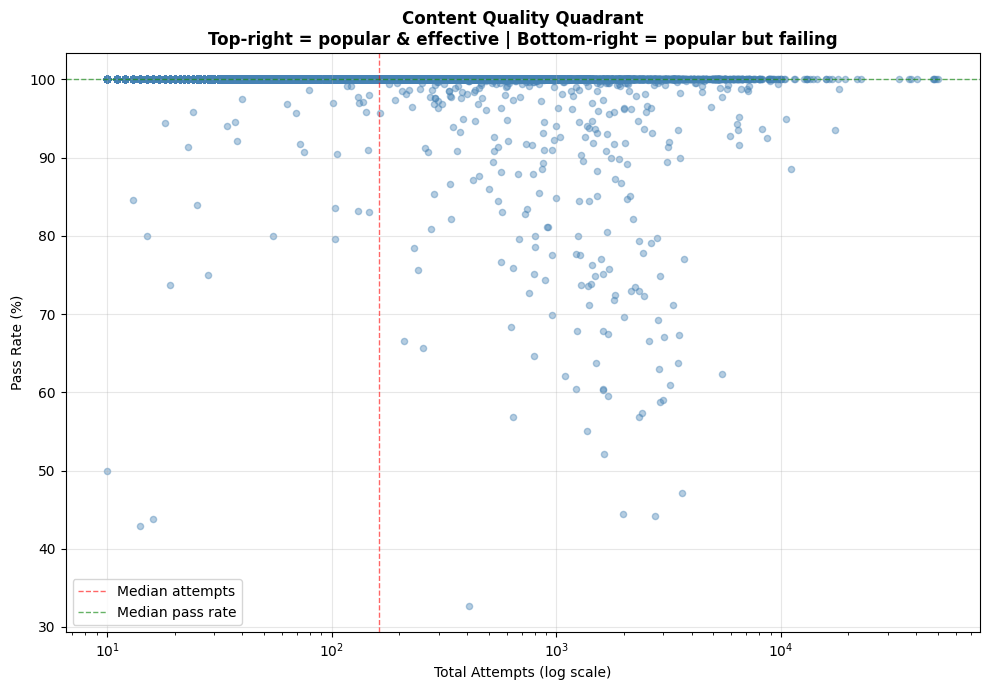


⚠️  High-volume, low-pass-rate content items: 4
These are the highest priority for content review:
learning_item_id  total_attempts  pass_rate  avg_score
             990            3634       47.1       63.2
             945            2758       44.2       64.3
             926            1979       44.4       57.4
            8982             407       32.7       32.7


In [15]:
# Content quality quadrant: volume vs pass rate
# High volume + low pass rate = content needs review
# High volume + high pass rate = content is working well
viz_content = content_stats[content_stats['total_attempts'] >= 10].copy()

plt.figure(figsize=(10, 7))
plt.scatter(
    viz_content['total_attempts'],
    viz_content['pass_rate'],
    alpha=0.4, s=20, c='steelblue'
)
median_attempts  = viz_content['total_attempts'].median()
median_pass_rate = viz_content['pass_rate'].median()
plt.axvline(median_attempts,  color='red',  linestyle='--', linewidth=1, alpha=0.6, label='Median attempts')
plt.axhline(median_pass_rate, color='green', linestyle='--', linewidth=1, alpha=0.6, label='Median pass rate')
plt.xscale('log')
plt.xlabel('Total Attempts (log scale)')
plt.ylabel('Pass Rate (%)')
plt.title('Content Quality Quadrant\nTop-right = popular & effective | Bottom-right = popular but failing',
          fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Flag content needing review: high volume but low pass rate
high_vol_low_pass = content_stats[
    (content_stats['total_attempts'] >= content_stats['total_attempts'].quantile(0.75)) &
    (content_stats['pass_rate'] < 50)
]
print(f'\n⚠️  High-volume, low-pass-rate content items: {len(high_vol_low_pass):,}')
print('These are the highest priority for content review:')
print(high_vol_low_pass.nlargest(10, 'total_attempts')[
    ['learning_item_id','total_attempts','pass_rate','avg_score']
].to_string(index=False))

ATTEMPT ORIGIN BREAKDOWN:
  ATM-PLAYER-MONSOON                      : 3,400,896 (51.7%)
  ATM-LMS-API-WEBHOOK-RUSTICI-ENGINE      : 2,891,594 (43.9%)
  ATM-PLAYER-SSLA                         : 188,880 (2.9%)
  ATM-PLAYER-STATIC                       : 73,504 (1.1%)
  ATM-PLAYER-DEFAULT__DOCUMENT            : 9,891 (0.2%)
  ATM-LMS-API__VIDEO                      : 8,785 (0.1%)
  ATM-PLAYER-DEFAULT__SCORM               : 3,899 (0.1%)
  ATM-PLAYER-SCORM12                      : 2,266 (0.0%)
  motorola insiders                       : 61 (0.0%)
  CONDUIT-PLAYER-SCORM12                  : 4 (0.0%)


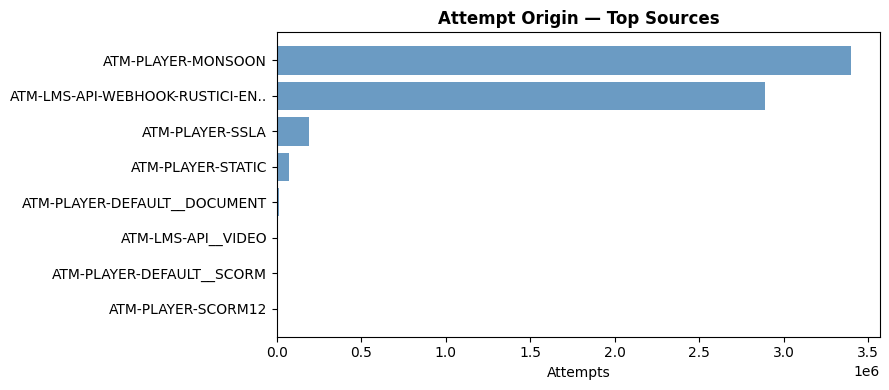

In [16]:
# ORIGIN ANALYSIS — where do attempts come from?
if 'origin' in li_clean.columns:
    origin_counts = li_clean['origin'].value_counts()
    print('ATTEMPT ORIGIN BREAKDOWN:')
    for origin, cnt in origin_counts.head(10).items():
        print(f'  {str(origin):<40}: {cnt:,} ({cnt/len(li_clean)*100:.1f}%)')

    plt.figure(figsize=(9, 4))
    top_origins = origin_counts.head(8)
    labels = [str(l)[:30] + '..' if len(str(l)) > 30 else str(l) for l in top_origins.index]
    plt.barh(labels[::-1], top_origins.values[::-1], color='steelblue', alpha=0.8)
    plt.title('Attempt Origin — Top Sources', fontweight='bold')
    plt.xlabel('Attempts')
    plt.tight_layout()
    plt.show()

---
## PART 5: PER-USER LEARNING FEATURE ENGINEERING
---

In [17]:
# ================================================================
# PER-USER LEARNING METRICS
# These are the cross-table features that 01_user_analysis couldn't
# compute because they require the raw attempt-level data.
# ================================================================
REFERENCE_DATE = pd.Timestamp('2025-11-01')

# Define time windows
cutoff_30d  = REFERENCE_DATE - pd.Timedelta(days=30)
cutoff_90d  = REFERENCE_DATE - pd.Timedelta(days=90)

def user_agg(df, cutoff=None, suffix=''):
    """Aggregate li_attempts per user, optionally filtered to a time window."""
    if cutoff is not None:
        df = df[df['start_ts'] >= cutoff]
    agg = df.groupby('user_id').agg(
        **{f'total_attempts{suffix}':  ('attempt_id',       'count')},
        **{f'passed_attempts{suffix}': ('is_pass',           'sum')},
        **{f'unique_li{suffix}':       ('learning_item_id', 'nunique')},
        **{f'avg_score{suffix}':       ('score',  lambda x: x[x>=0].mean() if (x>=0).any() else np.nan)},
        **{f'total_duration_mins{suffix}': ('duration_in_mins', 'sum')},
        **{f'active_days{suffix}':     ('start_ts', lambda x: x.dt.date.nunique())},
        **{f'last_attempt_ts{suffix}': ('start_ts', 'max')},
    ).reset_index()
    agg[f'pass_rate{suffix}'] = (
        agg[f'passed_attempts{suffix}'] / agg[f'total_attempts{suffix}']
    ).round(4)
    return agg

# All-time per-user stats
user_all  = user_agg(li_clean, suffix='_all')
# Last 30 days
user_30d  = user_agg(li_clean, cutoff=cutoff_30d, suffix='_30d')
# Last 90 days
user_90d  = user_agg(li_clean, cutoff=cutoff_90d, suffix='_90d')

# Merge all windows
user_li_features = user_all.merge(user_30d, on='user_id', how='left')
user_li_features = user_li_features.merge(user_90d, on='user_id', how='left')

# Fill 30d/90d nulls with 0 (user had no activity in that window)
fill_cols = [c for c in user_li_features.columns if c.endswith(('_30d','_90d'))
             and 'ts' not in c and 'rate' not in c]
user_li_features[fill_cols] = user_li_features[fill_cols].fillna(0)

print(f'Per-user learning features: {user_li_features.shape}')
print(f'Users with any learning activity: {len(user_li_features):,}')
print(f'\nFeature columns:')
print([c for c in user_li_features.columns if c != 'user_id'])

Per-user learning features: (147012, 25)
Users with any learning activity: 147,012

Feature columns:
['total_attempts_all', 'passed_attempts_all', 'unique_li_all', 'avg_score_all', 'total_duration_mins_all', 'active_days_all', 'last_attempt_ts_all', 'pass_rate_all', 'total_attempts_30d', 'passed_attempts_30d', 'unique_li_30d', 'avg_score_30d', 'total_duration_mins_30d', 'active_days_30d', 'last_attempt_ts_30d', 'pass_rate_30d', 'total_attempts_90d', 'passed_attempts_90d', 'unique_li_90d', 'avg_score_90d', 'total_duration_mins_90d', 'active_days_90d', 'last_attempt_ts_90d', 'pass_rate_90d']


Learning Recency Summary:
count    147012.0
mean        205.0
std         371.1
min        -128.0
25%         -75.0
50%          74.0
75%         372.0
max        1933.0
Name: days_since_last_attempt, dtype: float64


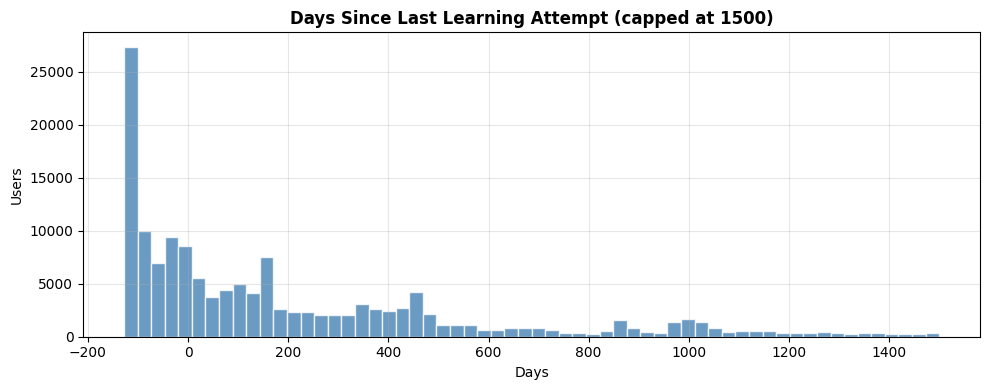

In [18]:
# Days since last attempt — learning recency signal
user_li_features['days_since_last_attempt'] = (
    REFERENCE_DATE - pd.to_datetime(user_li_features['last_attempt_ts_all'])
).dt.days

print('Learning Recency Summary:')
print(user_li_features['days_since_last_attempt'].describe().round(1))

# Distribution
plt.figure(figsize=(10, 4))
user_li_features['days_since_last_attempt'].clip(upper=1500).hist(
    bins=60, color='steelblue', alpha=0.8, edgecolor='white'
)
plt.title('Days Since Last Learning Attempt (capped at 1500)', fontweight='bold')
plt.xlabel('Days'); plt.ylabel('Users'); plt.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

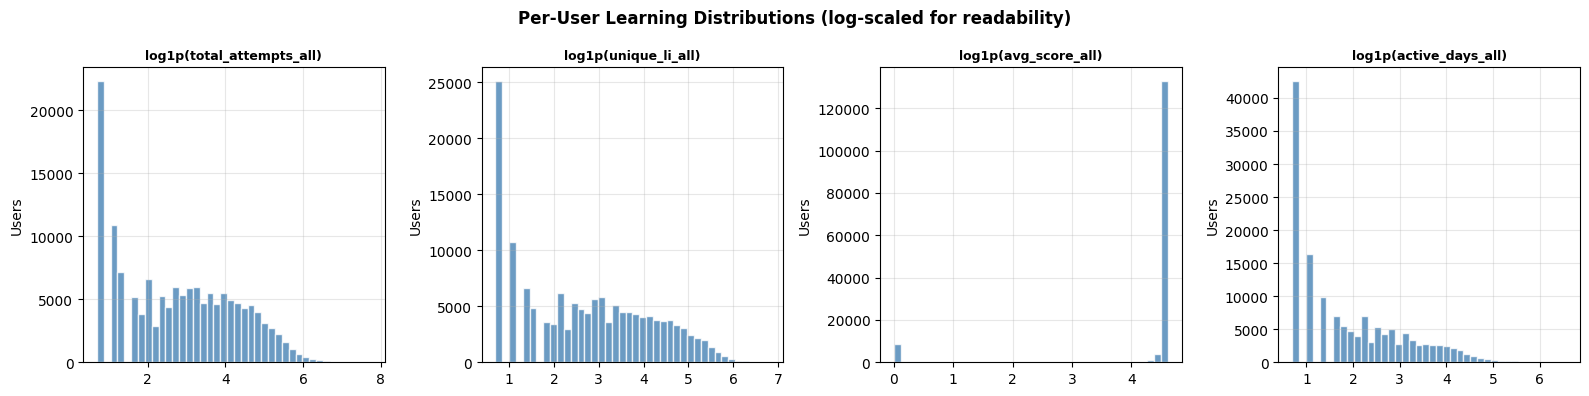

In [19]:
# DISTRIBUTION OF KEY USER METRICS
key_metrics = ['total_attempts_all','unique_li_all','avg_score_all','active_days_all']
key_metrics = [c for c in key_metrics if c in user_li_features.columns]

fig, axes = plt.subplots(1, len(key_metrics), figsize=(16, 4))
for i, col in enumerate(key_metrics):
    data = np.log1p(user_li_features[col].fillna(0))
    axes[i].hist(data, bins=40, color='steelblue', alpha=0.8, edgecolor='white')
    axes[i].set_title(f'log1p({col})', fontsize=9, fontweight='bold')
    axes[i].set_ylabel('Users')
    axes[i].grid(True, alpha=0.3)
plt.suptitle('Per-User Learning Distributions (log-scaled for readability)',
             fontweight='bold')
plt.tight_layout(); plt.show()

---
## PART 6: CROSS-TABLE ANALYSIS (li_attempts + users)
---

In [20]:
# Join learning features onto users table for cross-table analysis
users_with_li = users_biz.merge(user_li_features, on='user_id', how='left')

# Flag users with no learning activity
users_with_li['has_attempted_li'] = users_with_li['total_attempts_all'].notna().astype(int)
never_attempted = users_with_li['has_attempted_li'].eq(0).sum()

print(f'Users merged: {len(users_with_li):,}')
print(f'Users with any learning activity: {users_with_li["has_attempted_li"].sum():,}')
print(f'Users who NEVER attempted: {never_attempted:,} ({never_attempted/len(users_with_li)*100:.1f}%)')

Users merged: 295,765
Users with any learning activity: 146,577
Users who NEVER attempted: 149,188 (50.4%)


<Figure size 1400x500 with 0 Axes>

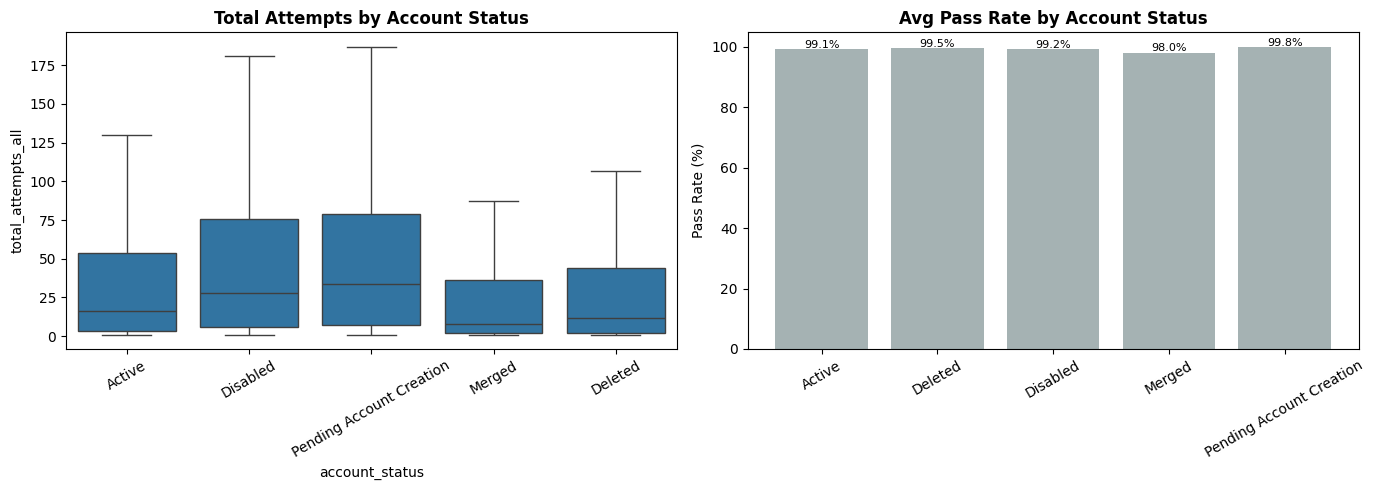

In [21]:
# Learning engagement by account status
plt.figure(figsize=(14, 5))
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Avg attempts by account status
status_top = users_with_li['account_status'].value_counts().head(5).index
status_df  = users_with_li[users_with_li['account_status'].isin(status_top)]
sns.boxplot(data=status_df, x='account_status', y='total_attempts_all',
            showfliers=False, ax=axes[0])
axes[0].set_title('Total Attempts by Account Status', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

# Pass rate by account status
pass_by_status = status_df.groupby('account_status')['pass_rate_all'].mean() * 100
colors_map = {'active':'#2ecc71','deleted':'#e74c3c','disabled':'#f39c12',
              'pending_creation':'#3498db','merged':'#9b59b6'}
bars = axes[1].bar(pass_by_status.index, pass_by_status.values,
                   color=[colors_map.get(s,'#95a5a6') for s in pass_by_status.index],
                   alpha=0.85)
axes[1].set_title('Avg Pass Rate by Account Status', fontweight='bold')
axes[1].set_ylabel('Pass Rate (%)')
axes[1].tick_params(axis='x', rotation=30)
for bar, val in zip(bars, pass_by_status.values):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.5, f'{val:.1f}%', ha='center', fontsize=8)
plt.tight_layout(); plt.show()

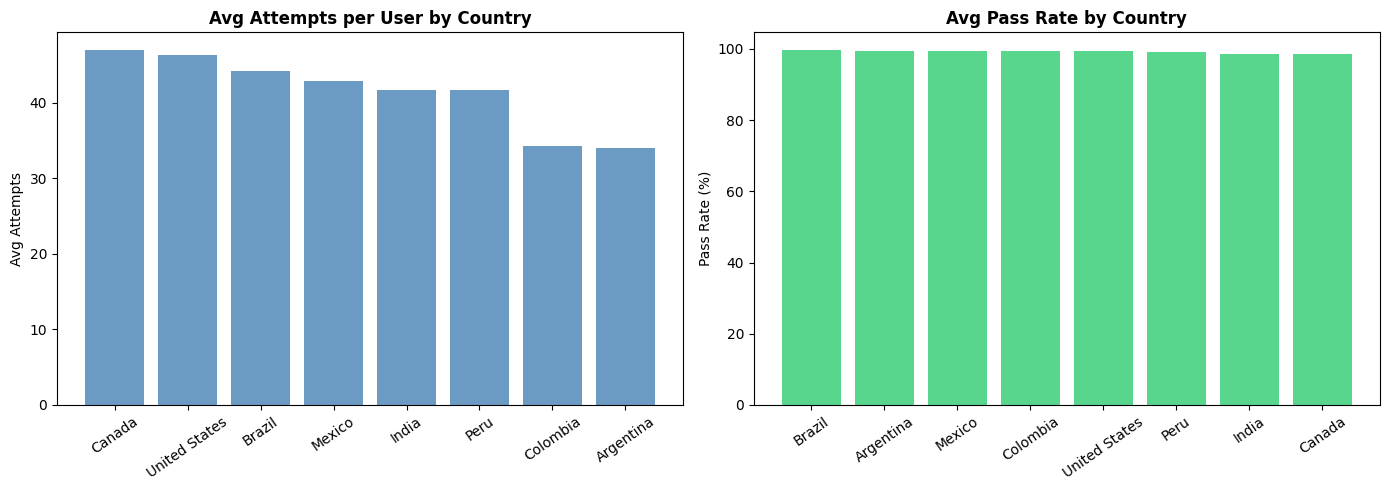

In [22]:
# Learning engagement by country (top 8)
country_top8 = users_with_li['country_name'].value_counts().head(8).index
country_df   = users_with_li[
    users_with_li['country_name'].isin(country_top8) &
    users_with_li['country_name'].ne('Unknown')
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
country_attempts = country_df.groupby('country_name')['total_attempts_all'].mean().sort_values(ascending=False)
axes[0].bar(country_attempts.index, country_attempts.values, color='steelblue', alpha=0.8)
axes[0].set_title('Avg Attempts per User by Country', fontweight='bold')
axes[0].tick_params(axis='x', rotation=35)
axes[0].set_ylabel('Avg Attempts')

country_pass = country_df.groupby('country_name')['pass_rate_all'].mean().sort_values(ascending=False) * 100
axes[1].bar(country_pass.index, country_pass.values, color='#2ecc71', alpha=0.8)
axes[1].set_title('Avg Pass Rate by Country', fontweight='bold')
axes[1].tick_params(axis='x', rotation=35)
axes[1].set_ylabel('Pass Rate (%)')
plt.tight_layout(); plt.show()

Top 10 Retailers — Learning Performance:
              retailer  users  avg_attempts  avg_pass_rate  avg_score
              T-Mobile  16326     49.962626      99.280732  98.405150
  All Allina Locations   8228     49.266170      98.674583  97.057241
                  AT&T   5673     48.157402      99.191764  98.144665
          Boost Mobile   8465     44.659657      99.741732  99.351660
TPR: T-Mobile Partners   3523     41.812663      99.988231  99.779929
              Motorola  18308     38.634966      99.413884  98.606450
               Cricket  17828     38.302319       99.94151  99.366185
                 Metro   8564     31.901067        99.9008  99.451859
     Otros - Argentina   5958     30.118999      99.672035  98.607025


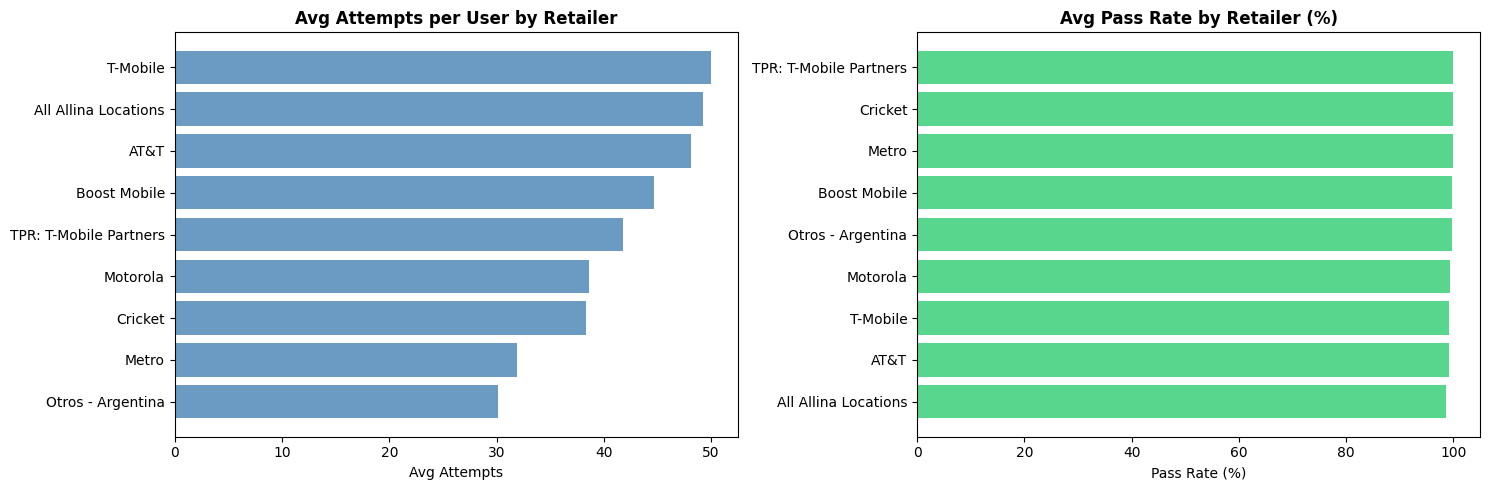

In [23]:
# Retailer learning performance (top 10)
retailer_top10 = users_with_li['retailer'].value_counts().head(10).index
retailer_df    = users_with_li[
    users_with_li['retailer'].isin(retailer_top10) &
    users_with_li['retailer'].ne('Unknown')
]

retailer_stats = retailer_df.groupby('retailer').agg(
    users         = ('user_id', 'count'),
    avg_attempts  = ('total_attempts_all', 'mean'),
    avg_pass_rate = ('pass_rate_all', 'mean'),
    avg_score     = ('avg_score_all', 'mean'),
).reset_index()
retailer_stats['avg_pass_rate'] = retailer_stats['avg_pass_rate'] * 100

print('Top 10 Retailers — Learning Performance:')
print(retailer_stats.sort_values('avg_attempts', ascending=False).to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sorted_r = retailer_stats.sort_values('avg_attempts', ascending=False)
axes[0].barh(sorted_r['retailer'][::-1], sorted_r['avg_attempts'][::-1],
             color='steelblue', alpha=0.8)
axes[0].set_title('Avg Attempts per User by Retailer', fontweight='bold')
axes[0].set_xlabel('Avg Attempts')

sorted_rp = retailer_stats.sort_values('avg_pass_rate', ascending=False)
axes[1].barh(sorted_rp['retailer'][::-1], sorted_rp['avg_pass_rate'][::-1],
             color='#2ecc71', alpha=0.8)
axes[1].set_title('Avg Pass Rate by Retailer (%)', fontweight='bold')
axes[1].set_xlabel('Pass Rate (%)')
plt.tight_layout(); plt.show()

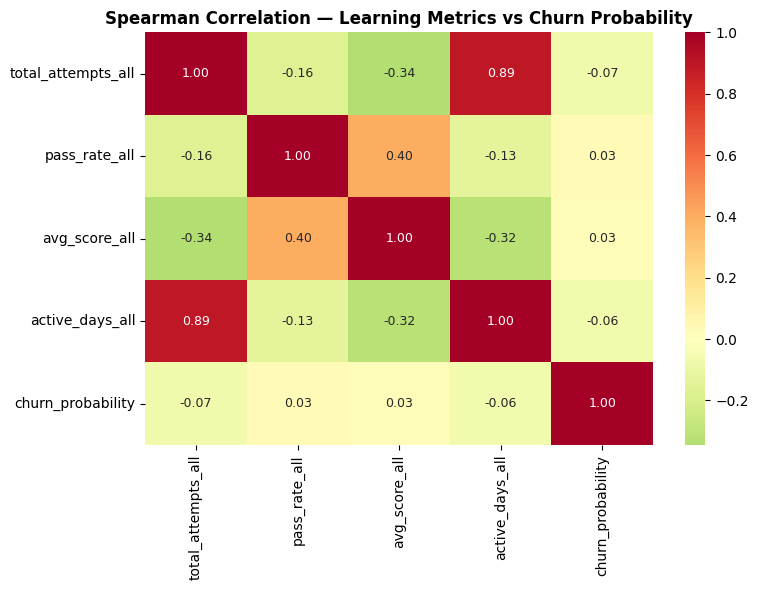

Negative correlation with churn_probability = more learning → less churn


In [24]:
# Correlation: learning engagement vs churn probability
if 'churn_probability' in users_with_li.columns:
    corr_cols = ['total_attempts_all','pass_rate_all','avg_score_all',
                 'active_days_all','churn_probability']
    corr_cols = [c for c in corr_cols if c in users_with_li.columns]
    spearman_li = users_with_li[corr_cols].dropna().corr(method='spearman')

    plt.figure(figsize=(8, 6))
    sns.heatmap(spearman_li, annot=True, cmap='RdYlGn_r',
                center=0, fmt='.2f', annot_kws={'size': 9})
    plt.title('Spearman Correlation — Learning Metrics vs Churn Probability',
              fontweight='bold')
    plt.tight_layout()
    plt.show()
    print('Negative correlation with churn_probability = more learning → less churn')

---
## PART 7: DASHBOARD METRIC SUMMARY
---

In [25]:
# ================================================================
# COMPUTE FINAL DASHBOARD METRICS
# These feed directly into the live dashboard
# ================================================================
total_attempts         = len(li_clean)
total_users_attempted  = li_clean['user_id'].nunique()
overall_pass_rate      = li_clean['is_pass'].mean() * 100
overall_avg_score      = scored['score'].mean()
avg_attempts_per_user  = total_attempts / total_users_attempted
avg_duration_per_attem = li_clean['duration_in_mins'][li_clean['duration_in_mins'] > 0].mean()

# 30-day window
li_30d = li_clean[li_clean['start_ts'] >= cutoff_30d]
attempts_30d          = len(li_30d)
unique_users_30d      = li_30d['user_id'].nunique()
pass_rate_30d         = li_30d['is_pass'].mean() * 100 if len(li_30d) > 0 else 0

print('=== DASHBOARD METRIC SNAPSHOT ===')
print(f'Total Attempts (all time):       {total_attempts:>12,}')
print(f'Total Users Who Attempted:       {total_users_attempted:>12,}')
print(f'Overall Pass Rate:               {overall_pass_rate:>11.1f}%')
print(f'Overall Avg Score (scored only): {overall_avg_score:>12.1f}')
print(f'Avg Attempts per User:           {avg_attempts_per_user:>12.1f}')
print(f'Avg Duration per Attempt (min):  {avg_duration_per_attem:>12.1f}')
print(f'Attempts Last 30 Days:           {attempts_30d:>12,}')
print(f'Unique Active Learners (30d):    {unique_users_30d:>12,}')
print(f'Pass Rate Last 30 Days:          {pass_rate_30d:>11.1f}%')

=== DASHBOARD METRIC SNAPSHOT ===
Total Attempts (all time):          6,579,780
Total Users Who Attempted:            147,012
Overall Pass Rate:                      99.1%
Overall Avg Score (scored only):         98.3
Avg Attempts per User:                   44.8
Avg Duration per Attempt (min):          14.5
Attempts Last 30 Days:              1,601,733
Unique Active Learners (30d):          66,958
Pass Rate Last 30 Days:                 98.4%


---
## PART 8: SAVE OUTPUTS
---

In [26]:
import os
PROJECT_ROOT = os.path.abspath('..')
MART_PATH    = os.path.join(PROJECT_ROOT, 'data', 'marts')
os.makedirs(MART_PATH, exist_ok=True)

# 1. Per-user learning feature mart
li_mart_path = os.path.join(MART_PATH, 'li_attempts_metrics.parquet')
user_li_features.to_parquet(li_mart_path, index=False)
print(f'✅ li_attempts_metrics      → {li_mart_path}  {user_li_features.shape}')

# 2. Content performance table
content_path = os.path.join(MART_PATH, 'content_performance.parquet')
content_stats.to_parquet(content_path, index=False)
print(f'✅ content_performance      → {content_path}  {content_stats.shape}')

# 3. Monthly attempt trends
monthly_attempts_save = monthly_attempts.copy()
monthly_attempts_save['attempt_month'] = monthly_attempts_save['attempt_month'].astype(str)
monthly_path = os.path.join(MART_PATH, 'monthly_attempts.parquet')
monthly_attempts_save.to_parquet(monthly_path, index=False)
print(f'✅ monthly_attempts         → {monthly_path}')

# 4. Dashboard metric snapshot as JSON for the Flask app
import json
snapshot = {
    'total_attempts':          int(total_attempts),
    'total_users_attempted':   int(total_users_attempted),
    'overall_pass_rate_pct':   round(float(overall_pass_rate), 1),
    'overall_avg_score':       round(float(overall_avg_score), 1),
    'avg_attempts_per_user':   round(float(avg_attempts_per_user), 1),
    'avg_duration_mins':       round(float(avg_duration_per_attem), 1),
    'attempts_30d':            int(attempts_30d),
    'unique_active_learners_30d': int(unique_users_30d),
    'pass_rate_30d_pct':       round(float(pass_rate_30d), 1),
}
snap_path = os.path.join(MART_PATH, 'li_dashboard_snapshot.json')
with open(snap_path, 'w') as f:
    json.dump(snapshot, f, indent=2)
print(f'✅ li_dashboard_snapshot    → {snap_path}')
print(f'   Content: {json.dumps(snapshot, indent=2)}')
print('\n🎉 All li_attempts outputs saved!')

✅ li_attempts_metrics      → d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence\data\marts\li_attempts_metrics.parquet  (147012, 26)
✅ content_performance      → d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence\data\marts\content_performance.parquet  (13037, 7)
✅ monthly_attempts         → d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence\data\marts\monthly_attempts.parquet
✅ li_dashboard_snapshot    → d:\Sourav\St CLair\Sem 4\Capstone Project 2\Halight-Performance-Intelligence\Halight-Performance-Intelligence\data\marts\li_dashboard_snapshot.json
   Content: {
  "total_attempts": 6579780,
  "total_users_attempted": 147012,
  "overall_pass_rate_pct": 99.1,
  "overall_avg_score": 98.3,
  "avg_attempts_per_user": 44.8,
  "avg_duration_mins": 14.5,
  "attempts_30d": 1601733,
  "unique_active_learners_30d": 66958

---
## Analysis Complete — Summary

| Output | File | Dashboard Page |
|--------|------|----------------|
| Per-user learning features | `data/marts/li_attempts_metrics.parquet` | Page 3, 4 |
| Content performance stats | `data/marts/content_performance.parquet` | Page 3 |
| Monthly attempt trends | `data/marts/monthly_attempts.parquet` | Page 1, 2 |
| Dashboard metric snapshot | `data/marts/li_dashboard_snapshot.json` | Page 1 |

### Key Metrics Produced for Dashboard
| Metric | Column | Dashboard Use |
|--------|--------|---------------|
| Total Attempts | `total_attempts_all` | Page 1 KPI card |
| Avg Attempts per User | computed | Page 3 KPI |
| Avg Score | `avg_score_all` | Page 3 KPI |
| Active Learning Days | `active_days_all` | Page 3 |
| Pass Rate | `pass_rate_all` | Page 3 |
| Last 30d Attempts | `total_attempts_30d` | Page 1, Page 4 targeting |
| Days Since Last Attempt | `days_since_last_attempt` | Page 4 churn features |

**Next: `05_feature_mart_creation.ipynb`** — join users + li_attempts + rewards + surveys into full feature mart